In [1]:
import os
import copy
import torch
from pathlib import Path
from stMVCL.stMVCL.config import set_arg
from stMVCL.stMVCL.data import *
from stMVCL.stMVCL.utils import *
from stMVCL.stMVCL.stMVCL import *
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt
from sklearn.metrics.cluster import adjusted_rand_score
from sklearn.metrics import normalized_mutual_info_score
from sklearn.metrics import homogeneity_score, completeness_score

In [2]:
os.environ['R_HOME'] = '/home/ZHX/anaconda3/envs/GraphST/lib/R'
current_path = os.getcwd()
print("当前路径：", current_path)
file_path=current_path
# gpu
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
# path
data_root = Path('/home/ZHX/Dataset/Mouse_embryos_E9.5_E1S1')
result_path = "/home/ZHX/code111/GraphST-main/final_result/stMVCL_result/"
#设置参数
opt = set_arg()
arg = opt.parse_args(['--epoch','400','--n_domain', '22','--radius', '1','--latent_dim','512']) # E9.5 22
print(arg)

当前路径： /home/ZHX/code111/GraphST-main/stMVCL/Tutorial
Namespace(epoch=400, hvg_n=3000, knn=6, latent_dim=512, log_step=10, lr=0.001, n_domain=22, n_refine=25, radius=1, seed=0, temp=0.05, weight_decay=0.0001)


In [3]:
sample_name = 'stereo_embryo9.5_epoch400_2'
adata = sc.read_h5ad(data_root / 'E9.5_E1S1.MOSTA.h5ad' )
adata.var_names_make_unique()
print("=============原始{}切片信息，带ground truth===============".format(sample_name))
print(adata)

=============原始stereo_embryo9.5_epoch400_2切片信息，带ground truth===============
AnnData object with n_obs × n_vars = 5913 × 25568
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'annotation', 'Regulon - 2310011J03Rik', 'Regulon - 5730507C01Rik', 'Regulon - Alx1', 'Regulon - Alx3', 'Regulon - Alx4', 'Regulon - Ar', 'Regulon - Arid3a', 'Regulon - Arid3c', 'Regulon - Arnt2', 'Regulon - Arx', 'Regulon - Ascl1', 'Regulon - Atf1', 'Regulon - Atf4', 'Regulon - Atf5', 'Regulon - Atf6', 'Regulon - Atf7', 'Regulon - Bach1', 'Regulon - Bach2', 'Regulon - Barhl1', 'Regulon - Barx1', 'Regulon - Batf', 'Regulon - Bcl11a', 'Regulon - Bcl3', 'Regulon - Bcl6', 'Regulon - Bcl6b', 'Regulon - Bclaf1', 'Regulon - Bdp1', 'Regulon - Bhlha15', 'Regulon - Bhlhe22', 'Regulon - Bhlhe23', 'Regulon - Bhlhe41', 'Regulon - Bmyc', 'Regulon - Boll', 'Regulon - Bptf', 'Regulon - Brca1', 'Regulon - Brf1', 'Regulon - Brf2', 'Regulon - Bsx', 'Regulon - Cdx1', 'Regulon - Cdx2', 'R

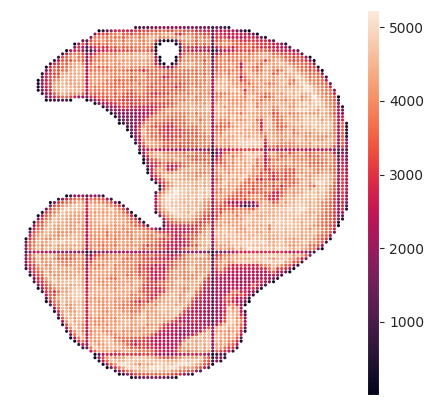

In [4]:
out_path = os.path.join(result_path , sample_name)
# 检查文件夹是否存在，如果不存在则创建文件夹
if not os.path.exists(out_path):
    os.makedirs(out_path)

#绘制每个细胞/spot检测到的基因数量
plt.rcParams["figure.figsize"] = (5,5)
sc.pl.embedding(adata, basis="spatial", color="n_genes_by_counts", show=False)
plt.title("")
plt.axis('off')
plt.savefig(os.path.join(out_path,"stereo_embryo9.5_n_genes_by_counts.png"))

/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/preprocessing/_highly_variable_genes.py:64: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(


=============预处理后stereo_embryo9.5_epoch400_2切片信息===============
AnnData object with n_obs × n_vars = 5913 × 25568
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'annotation', 'Regulon - 2310011J03Rik', 'Regulon - 5730507C01Rik', 'Regulon - Alx1', 'Regulon - Alx3', 'Regulon - Alx4', 'Regulon - Ar', 'Regulon - Arid3a', 'Regulon - Arid3c', 'Regulon - Arnt2', 'Regulon - Arx', 'Regulon - Ascl1', 'Regulon - Atf1', 'Regulon - Atf4', 'Regulon - Atf5', 'Regulon - Atf6', 'Regulon - Atf7', 'Regulon - Bach1', 'Regulon - Bach2', 'Regulon - Barhl1', 'Regulon - Barx1', 'Regulon - Batf', 'Regulon - Bcl11a', 'Regulon - Bcl3', 'Regulon - Bcl6', 'Regulon - Bcl6b', 'Regulon - Bclaf1', 'Regulon - Bdp1', 'Regulon - Bhlha15', 'Regulon - Bhlhe22', 'Regulon - Bhlhe23', 'Regulon - Bhlhe41', 'Regulon - Bmyc', 'Regulon - Boll', 'Regulon - Bptf', 'Regulon - Brca1', 'Regulon - Brf1', 'Regulon - Brf2', 'Regulon - Bsx', 'Regulon - Cdx1', 'Regulon - Cdx2', 'Regulon - Ceb

  0%|          | 0/400 [00:00<?, ?it/s]

 epoch:  0  feat_loss = 3.57  loss_sl_1 = 11.58  loss_sl_2 = 0.13  total_loss = 5.92


 11%|█         | 43/400 [00:03<00:30, 11.75it/s]

...

 81%|████████  | 323/400 [00:28<00:06, 11.12it/s]

 epoch:  320  feat_loss = 0.07  loss_sl_1 = 0.23  loss_sl_2 = 0.02  total_loss = 0.12


 91%|█████████ | 363/400 [00:32<00:03, 10.93it/s]

 epoch:  360  feat_loss = 0.07  loss_sl_1 = 0.20  loss_sl_2 = 0.02  total_loss = 0.11


100%|██████████| 400/400 [00:35<00:00, 11.15it/s]


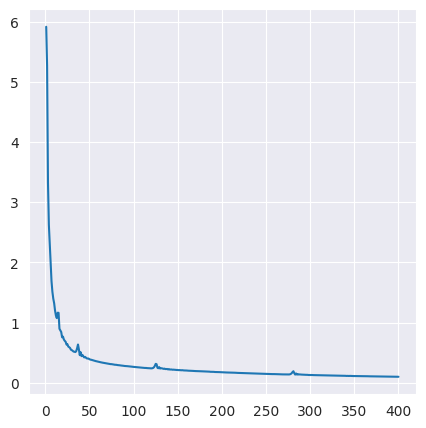

Completion of training


sh: warning: setlocale: LC_ALL: cannot change locale (en_US.UTF-8)
sh: warning: setlocale: LC_ALL: cannot change locale (en_US.UTF-8)
During startup - Warning messages:
1: Setting LC_CTYPE failed, using "C" 
2: Setting LC_COLLATE failed, using "C" 
3: Setting LC_TIME failed, using "C" 
4: Setting LC_MESSAGES failed, using "C" 
5: Setting LC_MONETARY failed, using "C" 
6: Setting LC_PAPER failed, using "C" 
7: Setting LC_MEASUREMENT failed, using "C" 
R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%
ARI = 0.3230
NMI = 0.6185
HS = 0.7300
CS = 0.5366


In [5]:
#preprocessing
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=3000)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
print("=============预处理后{}切片信息===============".format(sample_name))
print(adata)

# train model
adata = train(adata,arg)
print("Completion of training")
# clustering
adata = mclust_R(adata, arg.n_domain,used_obsm='stMVCL' )
# adata = mclust_R(adata, arg.n_domain,used_obsm='stMVCL' ,refine=True, n_refine=arg.n_refine)

# filter out NA nodes
obs_df = adata.obs.dropna()
ARI = adjusted_rand_score(obs_df['mclust'], obs_df['annotation'])
NMI = normalized_mutual_info_score(adata.obs['mclust'], adata.obs['annotation'])
HS = homogeneity_score(adata.obs['annotation'],adata.obs['mclust'])
CS = completeness_score(adata.obs['annotation'],adata.obs['mclust'])

adata.uns['ARI']=ARI
adata.uns['NMI']=NMI
adata.uns['HS']=HS
adata.uns['CS']=CS
print('ARI = %.4f' %ARI)
print('NMI = %.4f' %NMI)
print('HS = %.4f' %HS)
print('CS = %.4f' %CS)

/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


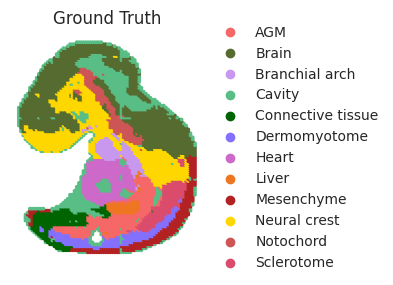

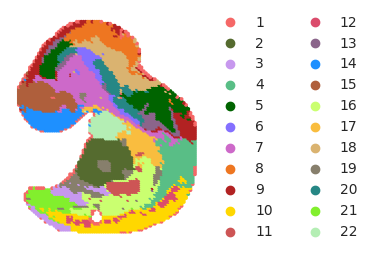

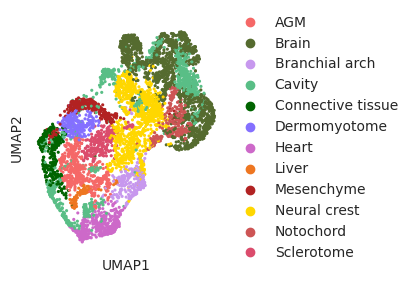

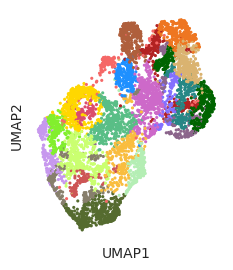

In [6]:

import matplotlib.pyplot as plt
adata.obsm['spatial'][:, 1] = -1*adata.obsm['spatial'][:, 1] # picture inversion
plt.rcParams["figure.figsize"] = (2.5, 3)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plot_color=["#F56867","#556B2F","#C798EE","#59BE86","#006400","#8470FF",
            "#CD69C9","#EE7621","#B22222","#FFD700","#CD5555","#DB4C6C",
            "#8B658B","#1E90FF","#AF5F3C","#CAFF70", "#F9BD3F","#DAB370",
          "#877F6C","#268785", '#82EF2D', '#B4EEB4']
sc.pl.embedding(adata, basis="spatial", color="annotation",s=30, show=False,palette=plot_color, frameon=False,title='Ground Truth')#,save='_stereo_embryo01.png'
plt.savefig(os.path.join(out_path,"{}_ground truth.png").format(sample_name))
sc.pl.embedding(adata, basis="spatial", color="mclust",s=30, show=False,palette=plot_color, title='')#,save='_stereo_embryo01.png'
plt.axis('off')
plt.savefig(os.path.join(out_path,"stereo_embryo9.5_clustering.png"))

sc.pp.neighbors(adata, use_rep='stMVCL')
sc.tl.umap(adata)
sc.pl.umap(adata, color='annotation', title='', show=False)
plt.savefig(os.path.join(out_path,"stereo_embryo9.5_ground_truth_umap.png"))
sc.pl.umap(adata, color='mclust', title='',legend_loc='none', show=False)
plt.savefig(os.path.join(out_path,"stereo_embryo9.5_umap.png"))


/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


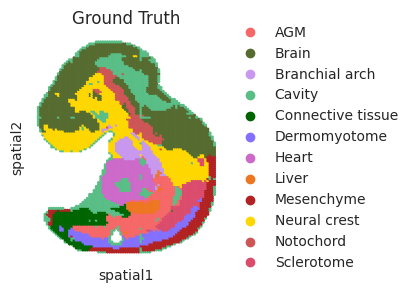

In [7]:
sc.pl.embedding(adata, basis="spatial",color="annotation", title="Ground Truth")


/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


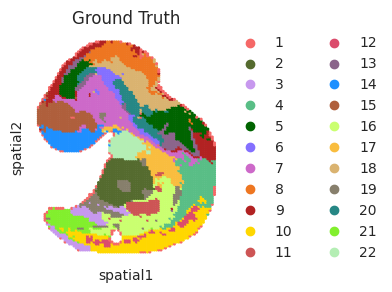

In [8]:
sc.pl.embedding(adata, basis="spatial",color="mclust", title="Ground Truth")


In [9]:
adata.obs['annotation'].unique()


['Cavity', 'Mesenchyme', 'Connective tissue', 'Dermomyotome', 'AGM', ..., 'Brain', 'Heart', 'Branchial arch', 'Neural crest', 'Notochord']
Length: 12
Categories (12, object): ['AGM', 'Brain', 'Branchial arch', 'Cavity', ..., 'Mesenchyme', 'Neural crest', 'Notochord', 'Sclerotome']

Cavity
Mesenchyme
Connective tissue


/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Dermomyotome
AGM
Liver


/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Sclerotome
Brain
Heart


/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Branchial arch
Neural crest
Notochord


/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


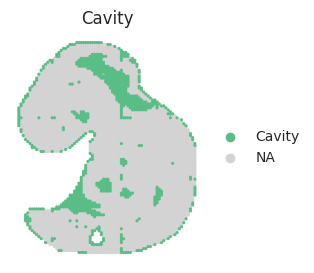

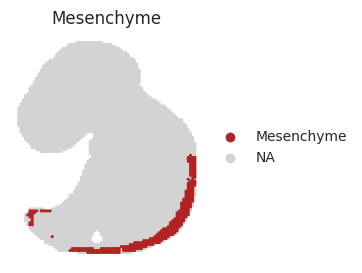

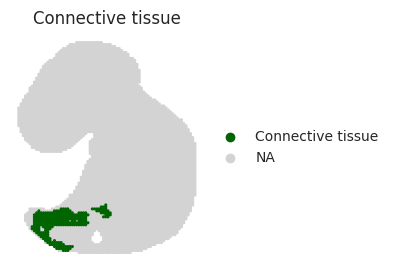

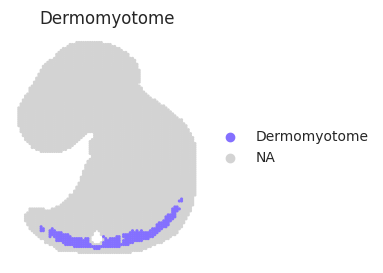

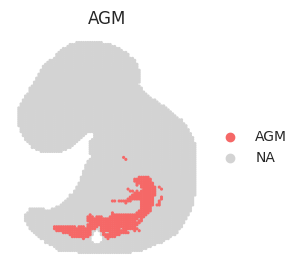

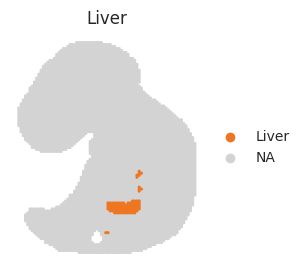

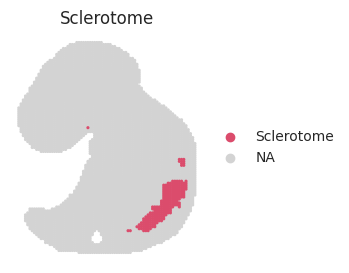

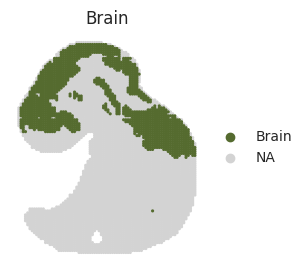

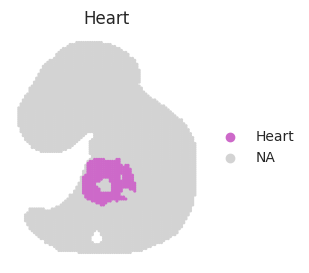

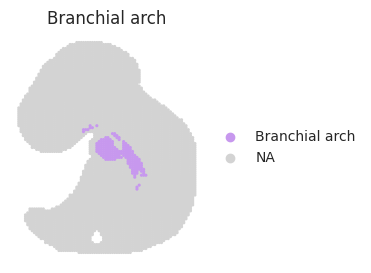

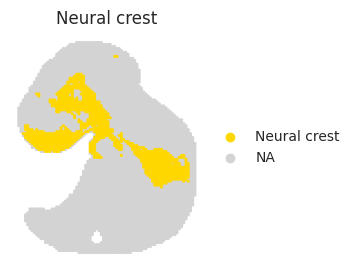

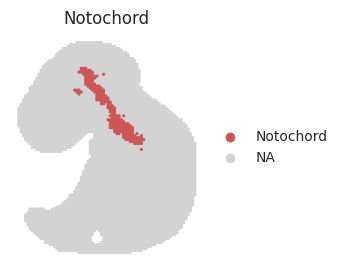

In [10]:
list=adata.obs['annotation'].unique()
for i in list:
    print(i)
    sc.pl.embedding(adata, basis="spatial",color="annotation", groups=[i], frameon=False,title=[i],show=False)
    plt.savefig(os.path.join(out_path,"ground_truth_{}.png").format(i))


In [11]:
adata.obs['mclust'].unique()

[10, 1, 3, 12, 21, ..., 20, 6, 15, 8, 18]
Length: 22
Categories (22, int64): [1, 2, 3, 4, ..., 19, 20, 21, 22]

10
1
3


/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


12
21
16


/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


19
4
11


...

/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


6
15
8


/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:244: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = pl.figure()
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormap

18


/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


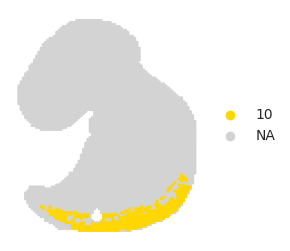

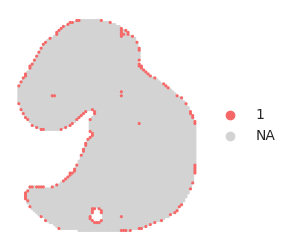

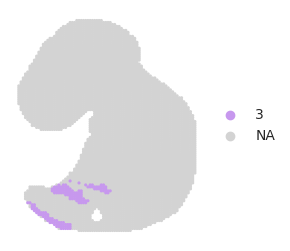

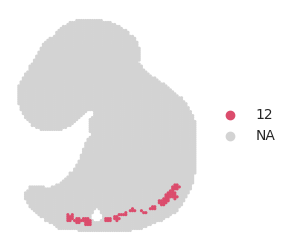

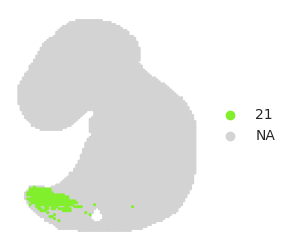

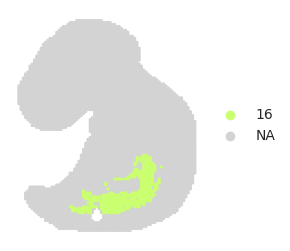

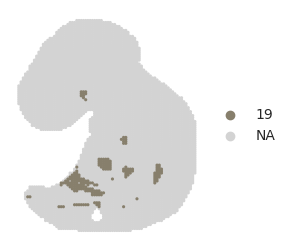

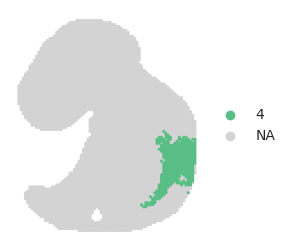

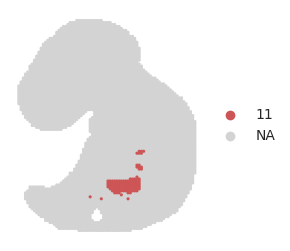

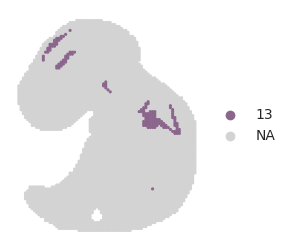

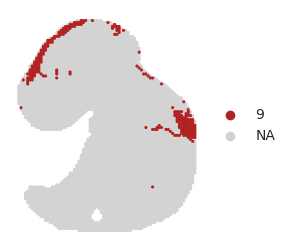

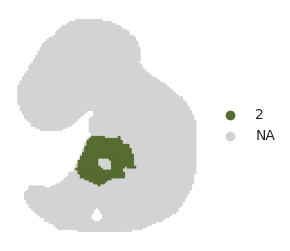

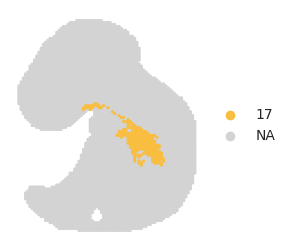

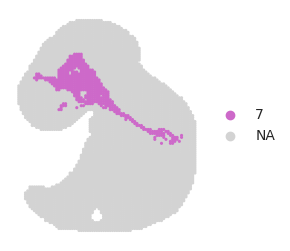

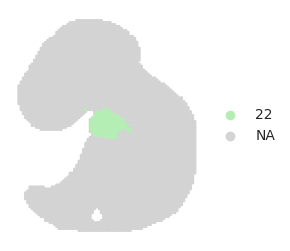

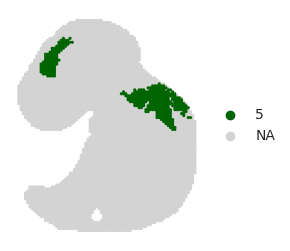

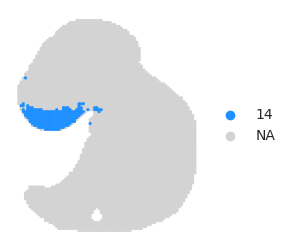

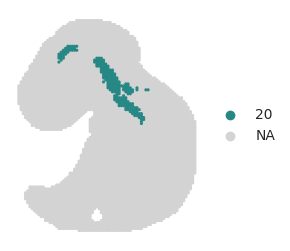

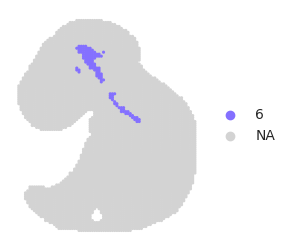

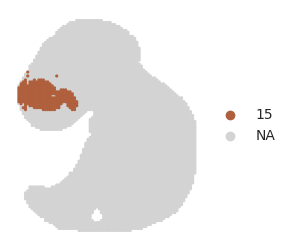

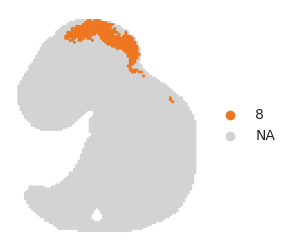

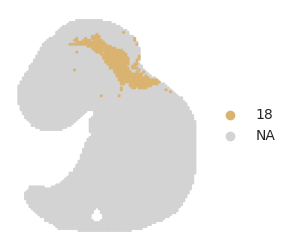

In [12]:
list=adata.obs['mclust'].unique()
for i in list:
    print(i)
    sc.pl.embedding(adata, basis="spatial",color="mclust", groups=[i], frameon=False,title='',show=False)
    plt.savefig(os.path.join(out_path,"cluster_{}.png").format(i))


In [13]:
# 将簇标签转换为字符串
adata.obs['mclust'] = adata.obs['mclust'].astype(str)
# 首先进行差异表达分析找到每个簇的标记基因
sc.tl.rank_genes_groups(adata, 'mclust', method='wilcoxon')

# 获取每个簇的标记基因（这里取每个簇的前3个标记基因）
n_top_genes = 8

# 为每个簇创建标记基因可视化
for cluster in adata.obs['mclust'].unique():
    print(f"Cluster {cluster}")

    # 1. 可视化簇的空间分布
    sc.pl.embedding(adata, basis="spatial", color="mclust",
                   groups=[cluster], frameon=False, title=f'Cluster {cluster}', show=False)
    plt.savefig(os.path.join(out_path, f"cluster_{cluster}.png"))
    plt.close()

    # 2. 获取该簇的top标记基因
    top_genes = sc.get.rank_genes_groups_df(adata, group=cluster)[:n_top_genes]['names'].tolist()

    # 3. 可视化每个标记基因的空间表达
    for gene in top_genes:
        if gene in adata.var_names:  # 确保基因存在
            # 创建图形并设置白色背景
            fig, ax = plt.subplots(figsize=(2.5, 3))
            fig.patch.set_facecolor('white')
            ax.set_facecolor('white')

            # 绘制基因表达图，使用蓝色系颜色映射
            sc.pl.embedding(adata, basis="spatial", color=gene,
                            title='',
                            frameon=False,
                            # legend_loc='none',
                           # title=f'{gene} in Cluster {cluster}',
                           cmap='viridis', show=False, ax=ax)

            # 保存图像
            plt.savefig(os.path.join(out_path, f"cluster_{cluster}_gene_{gene}.png"),
                       bbox_inches='tight', facecolor='white')
            plt.close()
        else:
            print(f"Warning: Gene {gene} not found in var_names")

# # 可选：保存标记基因结果到文件
# marker_genes_df = sc.get.rank_genes_groups_df(adata, group=None)
# marker_genes_df.to_csv(os.path.join(out_path, "marker_genes_all_clusters.csv"))
#
# # 可选：绘制所有簇的标记基因热图
# sc.pl.rank_genes_groups_heatmap(adata,
#                                groups=adata.obs['mclust'].unique().tolist(),
#                                n_genes=5,
#                                show_gene_labels=True,
#                                show=False)
# # 设置热图背景为白色
# plt.gcf().set_facecolor('white')
# plt.savefig(os.path.join(out_path, "marker_genes_heatmap.png"),
#            bbox_inches='tight', facecolor='white')
# plt.close()

/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups.py:396: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'names'] = self.var_names[global_indices]
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups.py:398: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'scores'] = scores[global_indices]
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups.py:401: PerformanceWarni

Cluster 10
Cluster 1


/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Cluster 3


/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


...

/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Cluster 8


/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Cluster 18


/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


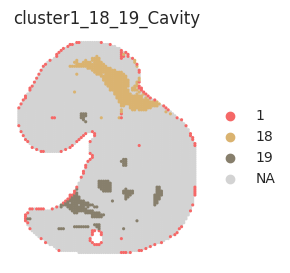

In [14]:
plt.rcParams["figure.figsize"] = (2.5, 3)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
sc.pl.embedding(adata, basis="spatial",color="mclust", groups=["1","18","19"], frameon=False,title='cluster1_18_19_Cavity',show=False)
plt.savefig(os.path.join(out_path,"cluster1_18_19_Cavity.png"))

/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


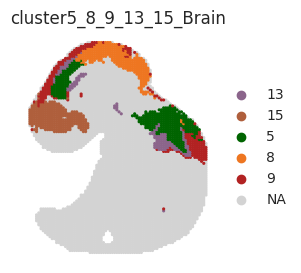

In [15]:
plt.rcParams["figure.figsize"] = (2.5, 3)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
sc.pl.embedding(adata, basis="spatial",color="mclust", groups=["5","8","9","15","13"], frameon=False,title='cluster5_8_9_13_15_Brain',show=False)
plt.savefig(os.path.join(out_path,"cluster5_8_9_13_15_Brain.png"))

/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


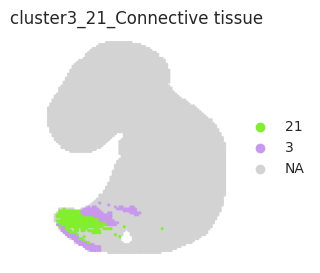

In [16]:
plt.rcParams["figure.figsize"] = (2.5, 3)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
sc.pl.embedding(adata, basis="spatial",color="mclust", groups=["3","21"], frameon=False,title='cluster3_21_Connective tissue',show=False)
plt.savefig(os.path.join(out_path,"cluster3_21_Connective tissue.png"))

/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


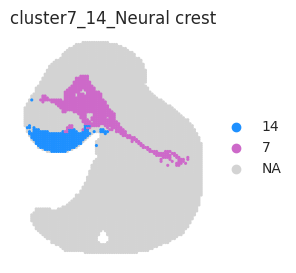

In [17]:
plt.rcParams["figure.figsize"] = (2.5, 3)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
sc.pl.embedding(adata, basis="spatial",color="mclust", groups=["7","14"], frameon=False,title='cluster7_14_Neural crest',show=False)
plt.savefig(os.path.join(out_path,"cluster7_14_Neural crest.png"))

/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


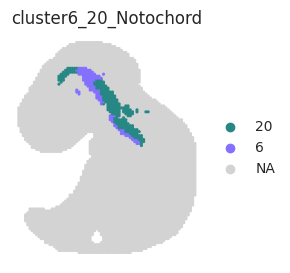

In [18]:
plt.rcParams["figure.figsize"] = (2.5, 3)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
sc.pl.embedding(adata, basis="spatial",color="mclust", groups=["6","20"], frameon=False,title='cluster6_20_Notochord',show=False)
plt.savefig(os.path.join(out_path,"cluster6_20_Notochord.png"))

/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


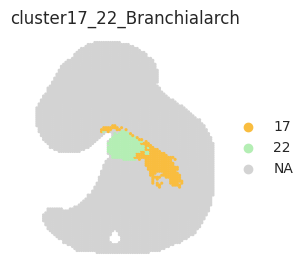

In [19]:
plt.rcParams["figure.figsize"] = (2.5, 3)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
sc.pl.embedding(adata, basis="spatial",color="mclust", groups=["17","22"], frameon=False,title='cluster17_22_Branchialarch',show=False)
plt.savefig(os.path.join(out_path,"cluster17_22_Branchialarch.png"))

In [20]:
# # 首先检查所有簇标签
# print("Available clusters:", adata.obs['mclust'].unique())
#
# # 然后进行差异表达分析
# sc.tl.rank_genes_groups(adata, 'mclust', method='t-test')
#
# # 检查差异表达分析结果中包含了哪些簇
# if 'rank_genes_groups' in adata.uns:
#     groups = list(adata.uns['rank_genes_groups']['names'].dtype.names)
#     print("Clusters in DEG results:", groups)

/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/tools/_paga.py:121: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['paga'] = {}
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/tools/_paga.py:127: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[groups + '_sizes'] = np.array(paga.ns)


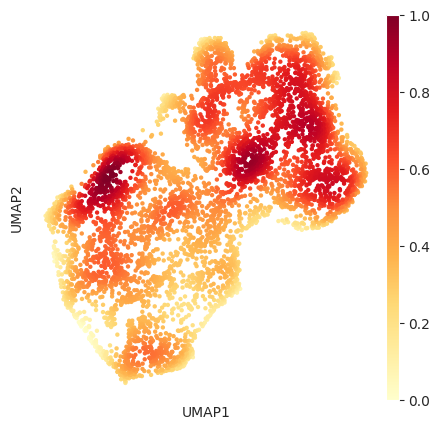

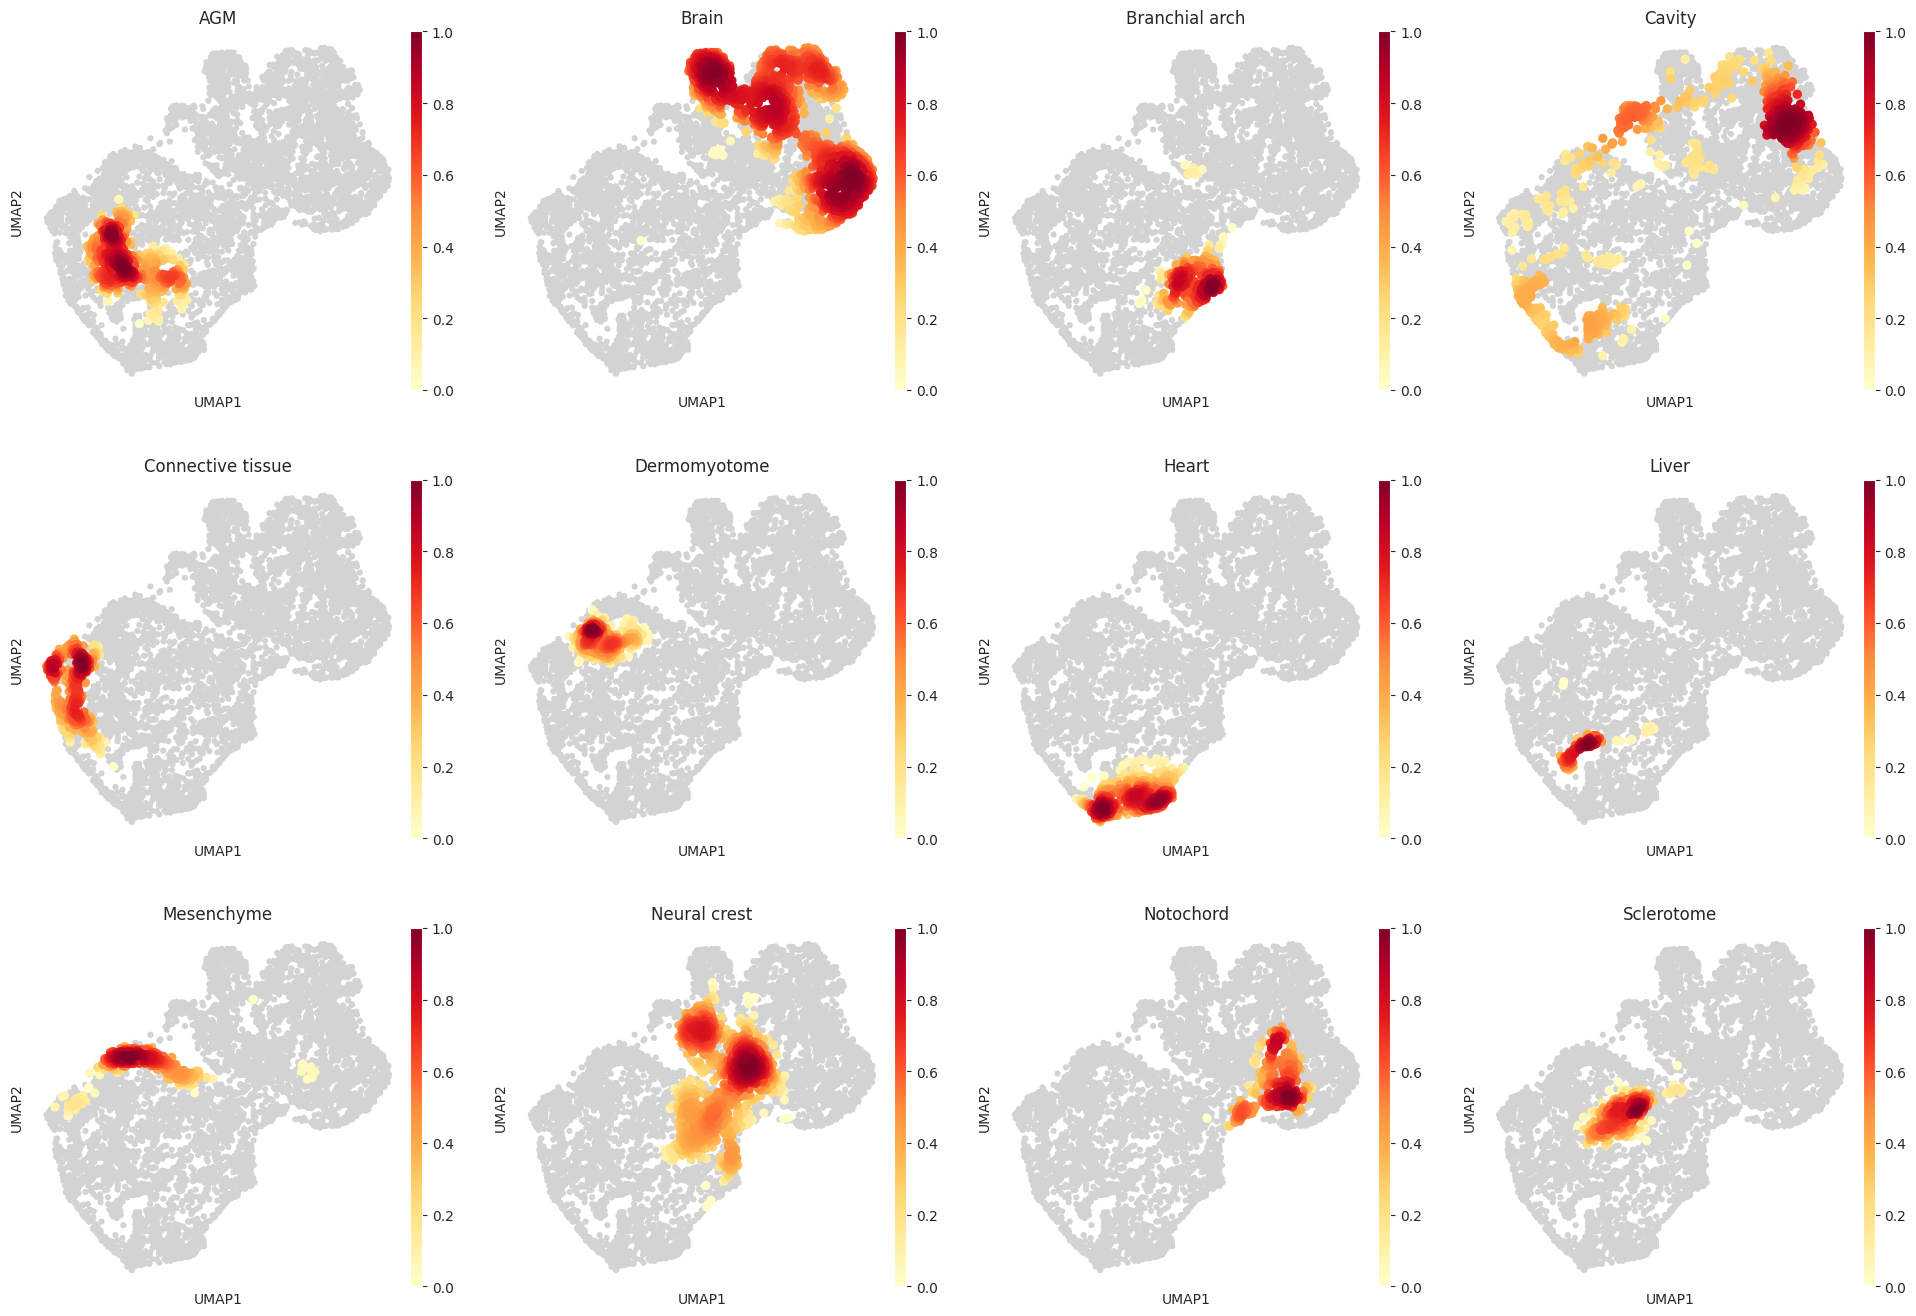

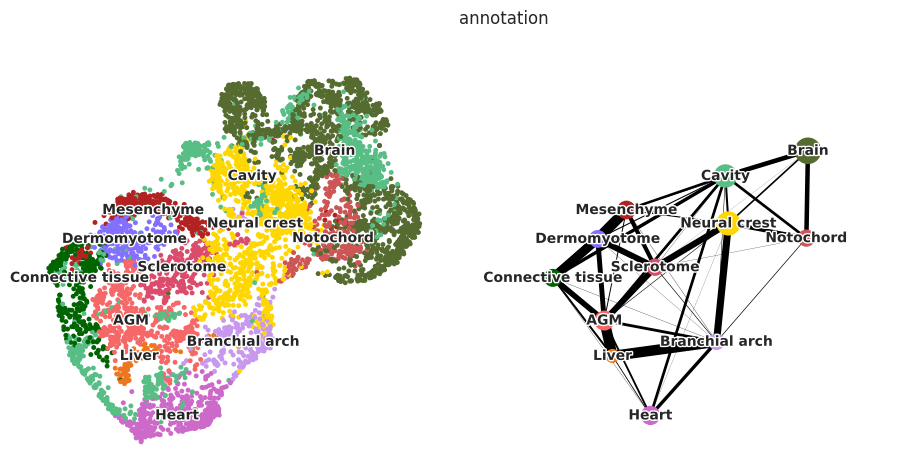

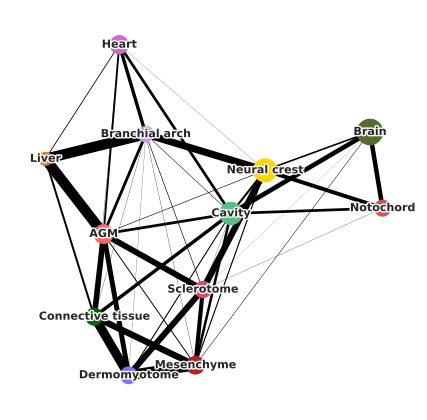

In [21]:
## heatmap of density
plt.rcParams["figure.figsize"] = (5, 5)
sc.tl.embedding_density(adata, basis='umap')
sc.pl.embedding_density(adata, basis='umap', fg_dotsize=40, show=False)
plt.savefig(os.path.join(out_path,"{}_heatmap of density.png").format(sample_name))

plt.rcParams["figure.figsize"] = (5, 5)
sc.tl.embedding_density(adata, basis='umap', groupby='annotation')
sc.pl.embedding_density(adata, basis='umap', groupby='annotation', show=False)
plt.savefig(os.path.join(out_path,"{}_heatmap of density_by_layer.png").format(sample_name))

## paga trajectory inference
adata = adata[adata.obs['annotation'].notna(), :]
sc.tl.paga(adata, groups='annotation')
plt.rcParams["figure.figsize"] = (5, 5)
sc.pl.paga_compare(adata, legend_fontsize=10, frameon=False, size=50,
                       legend_fontoutline=2, show=False)
plt.savefig(os.path.join(out_path,"{}_paga_compare.png").format(sample_name))

adata = adata[adata.obs['annotation'].notna(), :]
sc.tl.paga(adata, groups='annotation')
plt.rcParams["figure.figsize"] = (5, 5)
# 绘制标准PAGA图 (替换了paga_compare)
sc.pl.paga(adata,show=False,  frameon=False, fontoutline=2, fontsize=8)
plt.savefig(os.path.join(out_path,"{}_paga.png").format(sample_name),bbox_inches='tight',dpi=300)


         Falling back to preprocessing with `sc.pp.pca` and default params.


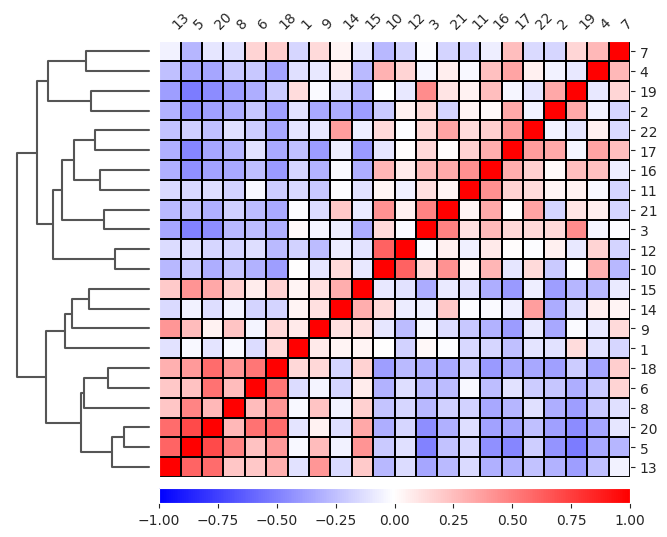

In [22]:
sc.pp.scale(adata, zero_center=False, max_value=10)
adata=adata[:, adata.var['highly_variable']]

sc.pl.correlation_matrix(adata, 'mclust', figsize=(8,6),show=False)
plt.savefig(os.path.join(out_path,"correlation_matrix.png"))


/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


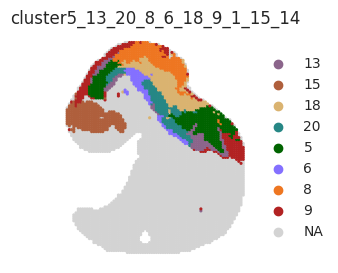

In [23]:
plt.rcParams["figure.figsize"] = (2.5, 3)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
sc.pl.embedding(adata, basis="spatial",color='mclust', groups=["5","13","20","8","6","18","9","15"], frameon=False,title='cluster5_13_20_8_6_18_9_1_15_14',show=False)
plt.savefig(os.path.join(out_path,"cluster5_13_20_8_6_18_9_15.png"))

/home/ZHX/anaconda3/envs/GraphST/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


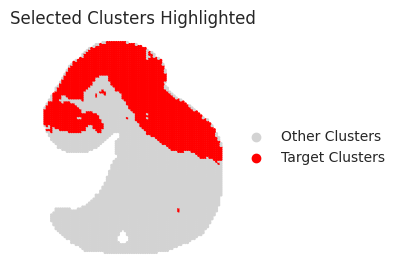

In [24]:
import matplotlib.pyplot as plt
import scanpy as sc
import os
import numpy as np

# 设置图形参数
plt.rcParams["figure.figsize"] = (2.5, 3)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

# 创建新的分类变量，将指定的簇标记为同一组
target_clusters = ["5", "13", "20", "8", "6", "18", "9", "15"]

# 假设聚类信息存储在adata.obs的'cluster'列中
# 创建一个新列来标记这些簇
adata.obs['highlighted_clusters'] = np.where(
    adata.obs['mclust'].isin(target_clusters),
    'Target Clusters',
    'Other Clusters'
)

# 设置颜色映射，使目标簇显示为特定颜色，其他簇显示为灰色
color_map = {
    'Target Clusters': 'red',  # 您可以更改为任何想要的颜色
    'Other Clusters': 'lightgray'
}

# 绘制空间转录组聚类图
sc.pl.embedding(
    adata,
    basis="spatial",
    color='highlighted_clusters',  # 使用新创建的列
    palette=color_map,  # 应用自定义颜色映射
    frameon=False,
    title='Selected Clusters Highlighted',
    show=False
)

# 确保输出目录存在
os.makedirs(out_path, exist_ok=True)

# 保存图像
plt.savefig(
    os.path.join(out_path, "highlighted_clusters.png"),
    dpi=300,
    bbox_inches="tight"
)

In [47]:
#这段代码首先使用GSEA分析整个表达矩阵，看基因集在两组之间的富集情况；然后使用差异表达分析找到两组之间的差异基因，并对上调的差异基因进行Enrichr富集分析，最后可视化富集结果
adata_g=adata
gene_sets_select = ['GO_Biological_Process_2023']
gene_sets_select

['GO_Biological_Process_2023']

In [48]:
#导入基因集并运行GSEA分析
import gseapy as gp
res = gp.gsea(data=adata_g.to_df().T, # row -> genes, column-> samples
        gene_sets=gene_sets_select,
        cls=adata_g.obs.highlighted_clusters,
        permutation_num=1000,
        permutation_type='phenotype',
        outdir=None,
        method='s2n', # signal_to_noise
        threads= 16)

In [49]:

res.res2d.head(10)

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,gsea,GO_Biological_Process_2023__Nervous System Dev...,-0.687919,-2.772451,0.0,0.0,0.0,36/83,8.00%,FABP7;HES5;POU3F2;MSI1;POU3F3;ADGRV1;FEZ1;ASCL...
1,gsea,GO_Biological_Process_2023__Generation Of Neur...,-0.738888,-2.718145,0.0,0.0,0.0,29/46,11.53%,POU3F2;TUBB2B;MAP1B;ASCL1;FZD3;DCC;RTN1;EN2;IN...
2,gsea,GO_Biological_Process_2023__Neuron Differentia...,-0.685413,-2.644799,0.0,0.0,0.0,25/52,6.80%,POU3F2;ASCL1;FZD3;PAX6;OTX2;RTN1;EN2;INSM1;SOX...
3,gsea,GO_Biological_Process_2023__Central Nervous Sy...,-0.701793,-2.585322,0.0,0.0,0.0,25/53,10.13%,HES5;MSI1;POU3F3;NES;PAX6;RTN1;ZIC1;NHLH2;TAGL...
4,gsea,GO_Biological_Process_2023__Neuron Projection ...,-0.816282,-2.567619,0.0,0.0,0.0,15/23,11.07%,SRGAP3;MAP1B;ADGRV1;STMN2;STMN3;OLIG3;PAK3;NEU...
5,gsea,GO_Biological_Process_2023__Extracellular Matr...,0.814302,2.563306,0.0,0.0,0.0,15/30,9.83%,COL3A1;COL1A2;POSTN;COL1A1;SERPINH1;FLRT2;COL4...
6,gsea,GO_Biological_Process_2023__Axon Development (...,-0.866392,-2.500937,0.0,0.0,0.0,11/17,7.30%,MAP1B;DCC;CTNNA2;OLIG3;PAK3;NEUROD4;FOLR1;LLGL...
7,gsea,GO_Biological_Process_2023__Heart Development ...,0.797627,2.464112,0.0,0.0,0.0,33/46,9.53%,GPC3;COL3A1;MYL7;HAND2;MYL2;MYH7;CSRP3;MYBPC3;...
8,gsea,GO_Biological_Process_2023__External Encapsula...,0.842799,2.441163,0.0,0.0,0.0,10/20,9.83%,COL3A1;COL1A2;POSTN;COL1A1;COL4A1;COL23A1;COL5...
9,gsea,GO_Biological_Process_2023__Extracellular Stru...,0.842799,2.441163,0.0,0.0,0.0,10/20,9.83%,COL3A1;COL1A2;POSTN;COL1A1;COL4A1;COL23A1;COL5...


In [50]:
res.ranking.shape

(3000,)

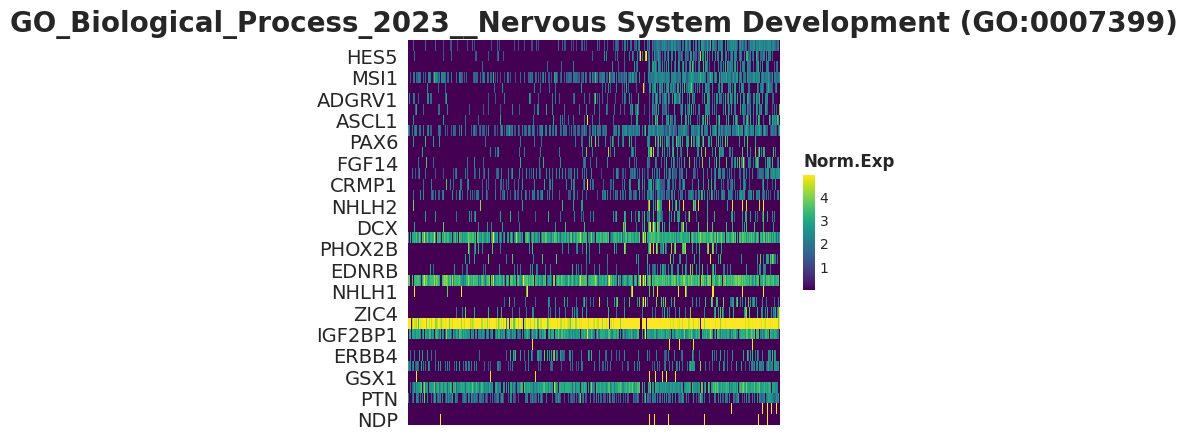

In [51]:
#查看GSEA结果并绘制热图
i = 0
genes = res.res2d.Lead_genes.iloc[i].split(";")
ax = gp.heatmap(df = res.heatmat.loc[genes],
           z_score=None,
           title=res.res2d.Term.iloc[i],
           figsize=(6,5),
           cmap=plt.cm.viridis,
           xticklabels=False)
# 保存图像
plt.savefig(
    os.path.join(out_path, "first_enrichment.png"),
    dpi=300,
    bbox_inches="tight"
)

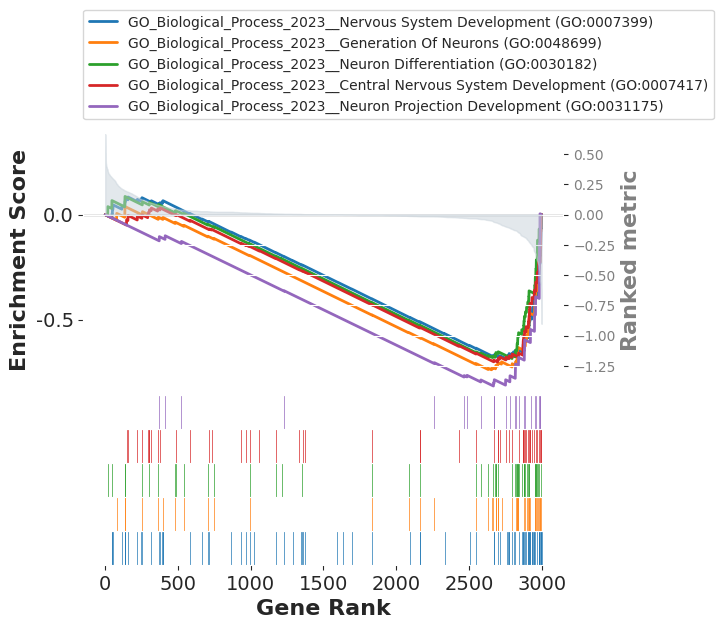

In [52]:
#绘制GSEA图,绘制前5个富集结果的GSEA图，显示每个基因集在排序列表中的富集情况
term = res.res2d.Term
# gp.gseaplot(res.ranking, term=term[i], **res.results[term[i]])
axs = res.plot(terms=term[:5])
# 保存图像
plt.savefig(
    os.path.join(out_path, "GSEA.png"),
    dpi=300,
    bbox_inches="tight"
)

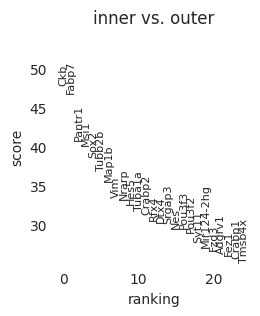

<Figure size 250x300 with 0 Axes>

In [53]:
#绘制差异表达基因的排名图，显示每个组的前25个基因
c1 = 'Target Clusters'
c2 = 'Other Clusters'
cluster_anno={c1:'inner',c2:'outer'}
adata_g.obs['domain_type']=adata_g.obs['highlighted_clusters'].astype('str').map(cluster_anno)
adata_g.X.max()
# find degs
sc.tl.rank_genes_groups(adata_g,
                        groupby='domain_type',
                        use_raw=False,

                        method='wilcoxon',
                        groups=["inner"],
                        reference='outer')
# 创建图形和轴对象
fig, ax = plt.subplots(figsize=(10, 8))

# 绘制差异表达基因的排名图到指定轴
sc.pl.rank_genes_groups(adata_g, n_genes=25, sharey=False, show=False, ax=ax)

# 保存图形
fig.savefig(
    os.path.join(out_path, "deg25.png"),
    dpi=300,
    bbox_inches="tight"
)

# 关闭图形
plt.close(fig)

In [54]:
#提取差异表达基因结果
result = adata_g.uns['rank_genes_groups']
groups = result['names'].dtype.names
degs = pd.DataFrame(
    {group + '_' + key: result[key][group]
    for group in groups for key in ['names','scores', 'pvals','pvals_adj','logfoldchanges']})

#筛选显著上调和下调的基因
degs_sig = degs[degs.inner_pvals_adj < 0.05]
degs_up = degs_sig[degs_sig.inner_logfoldchanges > 0]
degs_dw = degs_sig[degs_sig.inner_logfoldchanges < 0]
#对上调基因进行富集分析（Enrichr）
enr_up = gp.enrichr(degs_up.inner_names,
                    gene_sets=gene_sets_select,
                    outdir=None)

#处理富集分析结果的术语
enr_up.res2d.Term = enr_up.res2d.Term.str.split(" \(GO").str[0]

enr_up.res2d.Term



0                                 Neuron Differentiation
1                                  Generation Of Neurons
2                             Nervous System Development
3       Regulation Of Transcription By RNA Polymerase II
4              Regulation Of DNA-templated Transcription
                              ...                       
1637            Inorganic Cation Transmembrane Transport
1638                                          DNA Repair
1639          Positive Regulation Of Cytokine Production
1640                        Protein Modification Process
1641                              Organelle Organization
Name: Term, Length: 1642, dtype: object

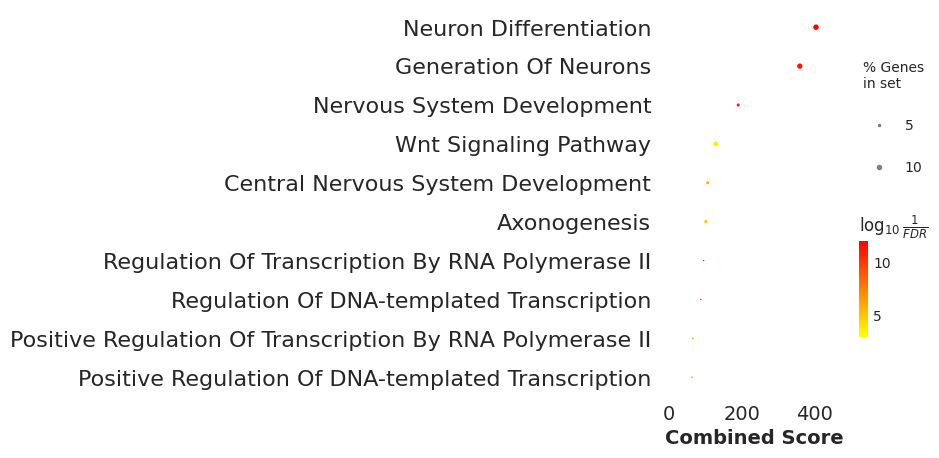

<Figure size 250x300 with 0 Axes>

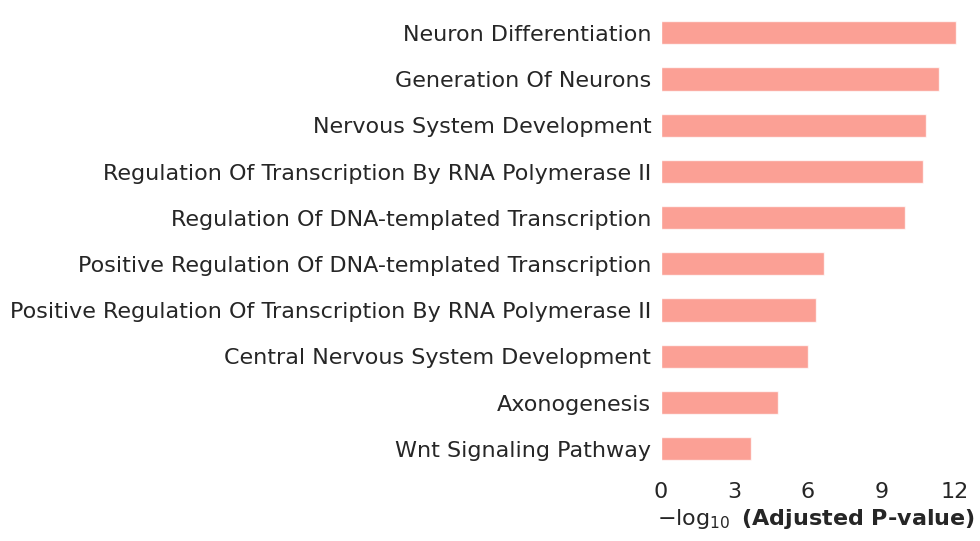

In [55]:
#使用gp.dotplot绘制点状图，显示富集结果，点的大小表示基因数，颜色表示富集显著性
# dotplot
gp.dotplot(enr_up.res2d, figsize=(3,5), title="", cmap = plt.cm.autumn_r, show = False)
# plt.show()
# 保存图像
plt.savefig(
    os.path.join(out_path, "enrichment_dotplot.png"),
    dpi=300,
    bbox_inches="tight"
)

#使用gp.barplot绘制条形图，显示富集结果的显著性（例如p值或调整后p值）

ax = gp.barplot(enr_up.res2d)
# 保存图像
plt.savefig(
    os.path.join(out_path, "enrichment_barplot.png"),
    dpi=300,
    bbox_inches="tight"
)

<Figure size 1200x1000 with 0 Axes>

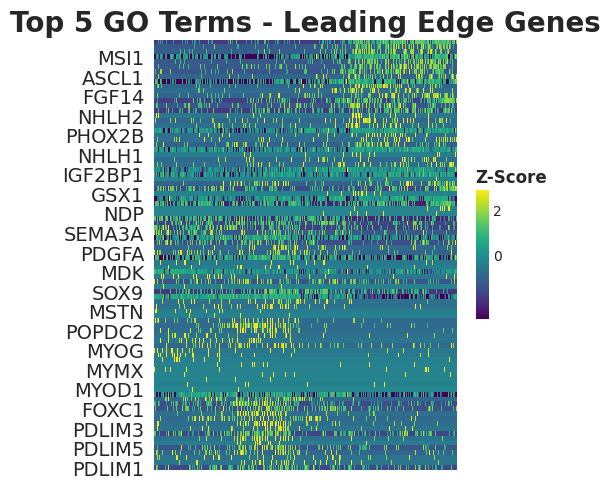

<Figure size 250x300 with 0 Axes>

In [56]:
# 选择前N个最显著的GO项
top_n = 5
significant_terms = res.res2d.sort_values(by='FDR q-val').head(top_n)

# 收集所有领先基因
all_genes = []
term_annotations = []  # 用于记录每个基因属于哪个GO项

for idx, row in significant_terms.iterrows():
    genes = row['Lead_genes'].split(';')
    all_genes.extend(genes)
    term_annotations.extend([row['Term']] * len(genes))

# 去重但保留顺序
unique_genes, indices = np.unique(all_genes, return_index=True)
unique_genes = unique_genes[np.argsort(indices)]

# 提取这些基因的表达数据
heatmap_data = res.heatmat.loc[unique_genes]

# 创建行注释（显示每个基因属于哪个GO项）
row_annotations = pd.DataFrame({'GO Term': [term_annotations[i] for i in np.argsort(indices)]},
                               index=unique_genes)

# 绘制热图
plt.figure(figsize=(12, 10))
ax = gp.heatmap(df=heatmap_data,
               z_score=0,  # 按行标准化
               title=f"Top {top_n} GO Terms - Leading Edge Genes",
               cmap=plt.cm.viridis,
               xticklabels=False,
                show = False,
               row_annotation=row_annotations)  # 添加行注释

plt.tight_layout()
# plt.show()
# 保存图像
plt.savefig(
    os.path.join(out_path, "top5_GO_terms_heatmap.png"),
    dpi=300,
    bbox_inches="tight"
)